# 01 · Irradiation loops and deformation lines with midas-ddd

This notebook builds the two dislocation populations a small-angle scattering simulation needs, checks them, and hands them to `midas_saxs/notebooks/01_saxs_image_from_dislocations.ipynb`:

* **irradiation loops**: Frank loops on the four {111} planes of Cu, with a size distribution and both characters (interstitial and vacancy);
* **deformation lines**: perfect dislocations on the twelve {111}<110> slip systems.

It does this two ways. First by hand with `midas_ddd.generate`, which needs nothing but `pip`. Then from a real **ExaDiS** run, through the ParaDiS `.data` file bridge. The files in `data/` were written by ExaDiS itself (script `data/generate_exadis_cu_networks.py`, ExaDiS commit `d550bc0`), so you do not need ExaDiS installed to use them.

**Install:** `pip install "midas-ddd>=0.2" "midas-saxs[dislocations]>=0.2" matplotlib`

**Units:** positions in micrometres, Burgers magnitudes in angstroms. Densities are printed in m⁻² (lines) and m⁻³ (loops).

In [1]:
import math
import tempfile
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
from mpl_toolkits.mplot3d.art3d import Line3DCollection

import midas_ddd
from midas_ddd import (
    combine, fcc_slip_systems, find_loops, prismatic_loop, read_paradis,
    relaxation_volumes_um3, straight_line, validate_network, write_paradis,
)

torch.set_default_dtype(torch.float64)
DATA = Path("data")
print("midas_ddd", midas_ddd.__version__)

midas_ddd 0.1.1


## 1 · Material and box

Copper. A perfect dislocation has $b = a/\sqrt{2}$ = 2.556 Å. A Frank loop has $b = a/3\langle111\rangle$, so $|b| = a/\sqrt{3}$ = 2.087 Å. That is expressed below as a scale factor on the perfect magnitude, because every network in one calculation shares one `b_magnitude_A`.

The box is a 1000 b cube (255.6 nm), the same as the ExaDiS files in section 4. The loop count gives about 1e22 m⁻³.

In [2]:
A_CU = 3.615                      # lattice parameter, angstrom
B_PERFECT = 2.556                 # a/sqrt(2) for a = 3.615 A; one b_magnitude_A for every network
FRANK = math.sqrt(2.0 / 3.0)      # |b_Frank| / |b_perfect|
BOX_UM = 1000 * 2.556e-4          # 0.2556 um
rng = torch.Generator().manual_seed(1)

## 2 · Irradiation loops by hand

`prismatic_loop` makes a closed polygon whose Burgers vector lies along its normal. Here the normals cycle through the four {111} planes. A negative `burgers_scale_b` turns an interstitial loop into a vacancy loop; the sign of the relaxation volume $\Delta V = \mathbf b\cdot\mathbf A$ follows it. Radii are log-normal around 5 nm.

**Watch the direction you pass as the normal.** `prismatic_loop` fixes the loop's circulation by a canonical normal, whose first non-zero component is positive. Passing (−1, 1, 1) therefore *also* flips the character, and cancels a negative `burgers_scale_b`. Write that plane as (1, −1, −1). The cell below prints the interstitial and vacancy counts so a slip here is visible.

**Pass the real box to `combine`.** Each generated loop carries its own small cell. Without `cell_size_um`, `combine` unions them, and `dislocation_density_um2()` comes out several times too low; `combine` warns when that happens.

In [3]:
normals = [(1, 1, 1), (1, 1, -1), (1, -1, 1), (1, -1, -1)]     # first non-zero component positive
n_loops = 167
radii_nm = torch.exp(math.log(5.0) + 0.25 * torch.randn(n_loops, generator=rng))
loops = []
for k in range(n_loops):
    centre = ((torch.rand(3, generator=rng) - 0.5) * BOX_UM).tolist()
    sign = 1.0 if k % 2 == 0 else -1.0                     # interstitial, vacancy
    loops.append(prismatic_loop(
        radius_um=float(radii_nm[k]) * 1e-3, burgers=normals[k % 4], n_segments=32,
        burgers_scale_b=sign * FRANK, b_magnitude_A=B_PERFECT, center_um=tuple(centre)))
loop_net = combine(loops, cell_size_um=BOX_UM)
sign_dV = torch.sign(relaxation_volumes_um3(loop_net, find_loops(loop_net)))
print(f"interstitial loops {int((sign_dV > 0).sum())}, vacancy loops {int((sign_dV < 0).sum())}")
loop_net

interstitial loops 84, vacancy loops 83


DislocationNetwork(5344 nodes, 5344 segments, b=2.556 A, cell=[0.2556, 0.2556, 0.2556] um)

## 3 · Deformation lines by hand

`straight_line` makes an open line of finite length. Each line below lies in its slip plane, at a random character angle θ between its line direction and its Burgers vector (0 = screw, 90° = edge), with alternating signs of b.

One caveat matters for scattering. **An open line that ends inside the crystal is not a real dislocation**, because Burgers vector cannot just stop. `straight_line` pins the two end nodes, and `validate_network` accepts that, but a scattering calculation sees those ends. The periodic ExaDiS lines in section 4 have no ends, which is why notebook 2 uses them.

In [4]:
systems = fcc_slip_systems()                   # 12 (plane normal, Burgers vector) pairs
n_lines = 24
parts = []
for k in range(n_lines):
    plane, burg = systems[k % 12]
    n_hat = torch.tensor(plane, dtype=torch.float64); n_hat = n_hat / n_hat.norm()
    b_hat = torch.tensor(burg, dtype=torch.float64); b_hat = b_hat / b_hat.norm()
    theta = float(torch.rand(1, generator=rng)) * math.pi
    t = math.cos(theta) * b_hat + math.sin(theta) * torch.linalg.cross(n_hat, b_hat)
    centre = ((torch.rand(3, generator=rng) - 0.5) * BOX_UM).tolist()
    sign = 1.0 if k % 2 == 0 else -1.0
    parts.append(straight_line(
        length_um=BOX_UM, burgers=tuple((sign * b_hat).tolist()), line=tuple(t.tolist()),
        slip_normal=plane, center_um=tuple(centre), n_segments=50, b_magnitude_A=B_PERFECT))
line_net = combine(parts, cell_size_um=BOX_UM)
line_net

DislocationNetwork(1224 nodes, 1200 segments, b=2.556 A, cell=[0.2556, 0.2556, 0.2556] um)

## 4 · Check what you built

`validate_network` checks three things.

* **Burgers conservation at every free node.** The scattering kernel needs it; a non-conserving network returns numbers that depend on arbitrary choices instead of an error.
* **Closed loops versus periodic lines.** A line in a periodic cell closes on itself *through* the boundary. It is not a loop: it encloses no area and has no relaxation volume. midas-ddd 0.1.x counted such lines as loops; they are now reported separately as `n_winding_lines`.
* **Resolution.** A polyline cannot represent structure finer than its segments. `q_max_supported` is the largest q at which the network still describes the dislocations rather than its own discretisation. Compare it with your detector's q range; 0.044 Å⁻¹ is the q_max of the detector in notebook 2.

In [5]:
def summarise(name, net, q_max_inv_A=0.044):
    s = validate_network(net, q_max_inv_A=q_max_inv_A)
    vol_m3 = net.cell_volume_um3 * 1e-18
    r = s["resolution"]
    print(f"{name}: {s['n_segments']} segments; Burgers conserved: {s['burgers_conserved']}")
    print(f"  closed loops {s['n_loops']} ({s['n_loops'] / vol_m3:.2e} m^-3); periodic lines {s['n_winding_lines']}")
    print(f"  line-length density {s['dislocation_density_um2'] * 1e12:.2e} m^-2")
    print(f"  median segment {r.median_length_um * 1e3:.2f} nm -> q_max supported {r.q_max_supported_inv_A:.3f} 1/A")
    for w in s["warnings"]:
        print("  note:", w)
    return s

_ = summarise("hand-built loops", loop_net)
_ = summarise("hand-built lines", line_net)

hand-built loops: 5344 segments; Burgers conserved: True
  closed loops 167 (1.00e+22 m^-3); periodic lines 0
  line-length density 3.18e+14 m^-2
  median segment 0.94 nm -> q_max supported 0.666 1/A


hand-built lines: 1200 segments; Burgers conserved: True
  closed loops 0 (0.00e+00 m^-3); periodic lines 0
  line-length density 3.67e+14 m^-2
  median segment 5.11 nm -> q_max supported 0.123 1/A


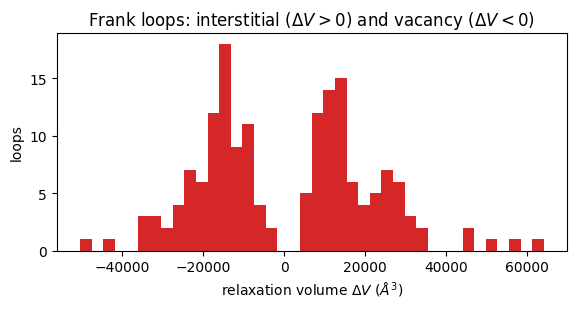

In [6]:
dV_A3 = relaxation_volumes_um3(loop_net, find_loops(loop_net)) * 1e12    # um^3 -> A^3
fig, ax = plt.subplots(figsize=(6, 3.2))
ax.hist(dV_A3.numpy(), bins=40, color="C3")
ax.set_xlabel(r"relaxation volume $\Delta V$ ($\AA^3$)")
ax.set_ylabel("loops")
ax.set_title("Frank loops: interstitial ($\\Delta V>0$) and vacancy ($\\Delta V<0$)")
plt.tight_layout()

## 5 · The ExaDiS file bridge

ExaDiS writes its networks in the ParaDiS `.data` format (`write_data`), and `read_paradis` reads them with no ExaDiS installed. The shipped files hold 167 perfect prismatic loops (radius 15-30 b) and 24 straight periodic lines (balanced ± b), both in a periodic 1000 b Cu cell. `data/exadis_cu_networks.json` records how they were generated.

**The file does not record |b|.** ParaDiS stores everything in units of b, so `b_magnitude_A` must come from the material. Get it wrong and the whole network is rescaled.

In [7]:
exa_loops = read_paradis(DATA / "exadis_cu_loops.data", b_magnitude_A=2.556)
exa_lines = read_paradis(DATA / "exadis_cu_lines.data", b_magnitude_A=2.556)
_ = summarise("ExaDiS loops", exa_loops)
_ = summarise("ExaDiS lines", exa_lines)
exa_both = combine([exa_loops, exa_lines], cell_min_um=exa_loops.cell_min_um, cell_max_um=exa_loops.cell_max_um)
exa_both

ExaDiS loops: 4044 segments; Burgers conserved: True
  closed loops 167 (1.00e+22 m^-3); periodic lines 0
  line-length density 2.27e+14 m^-2
  median segment 0.93 nm -> q_max supported 0.673 1/A
ExaDiS lines: 1680 segments; Burgers conserved: True
  closed loops 0 (0.00e+00 m^-3); periodic lines 24
  line-length density 5.20e+14 m^-2
  median segment 5.16 nm -> q_max supported 0.122 1/A
  note: 24 circuit(s) close only through the periodic boundary: infinite periodic lines, not loops. They enclose no area and carry no relaxation volume.


DislocationNetwork(5724 nodes, 5724 segments, b=2.556 A, cell=[0.2556, 0.2556, 0.2556] um)

### Check the character before you scatter

A screw dislocation has no dilatation in isotropic or cubic elasticity, so it has **no small-angle signal at all**. ExaDiS's `generate_line_config` balances the slip systems unless you pass `theta`, and for Cu that default produced 24 pure screws here: a SAXS frame of this file would be float64 roundoff. Notebook 2 therefore uses lines generated with `theta_deg=[0, 30, 60, 90]`.

In [8]:
from midas_ddd import winding_components

labels, n_comp, winds = winding_components(exa_lines)
d = exa_lines.segment_vectors_um()
t_hat = d / d.norm(dim=1, keepdim=True)
b_hat = exa_lines.burgers_b / exa_lines.burgers_b.norm(dim=1, keepdim=True)
angle = torch.rad2deg(torch.arccos((t_hat * b_hat).sum(dim=1).abs().clamp(max=1.0)))
per_line = torch.stack([angle[labels == c].median() for c in range(n_comp)])
print(f"{n_comp} periodic lines; character angle (0 = screw, 90 = edge): "
      f"min {float(per_line.min()):.2f}, max {float(per_line.max()):.2f} deg")

24 periodic lines; character angle (0 = screw, 90 = edge): min 0.00, max 0.00 deg


## 6 · Look at them

Segments are drawn with minimum-image vectors, so a periodic segment that crosses a face is drawn as a short stub at the face rather than as a line across the whole box.

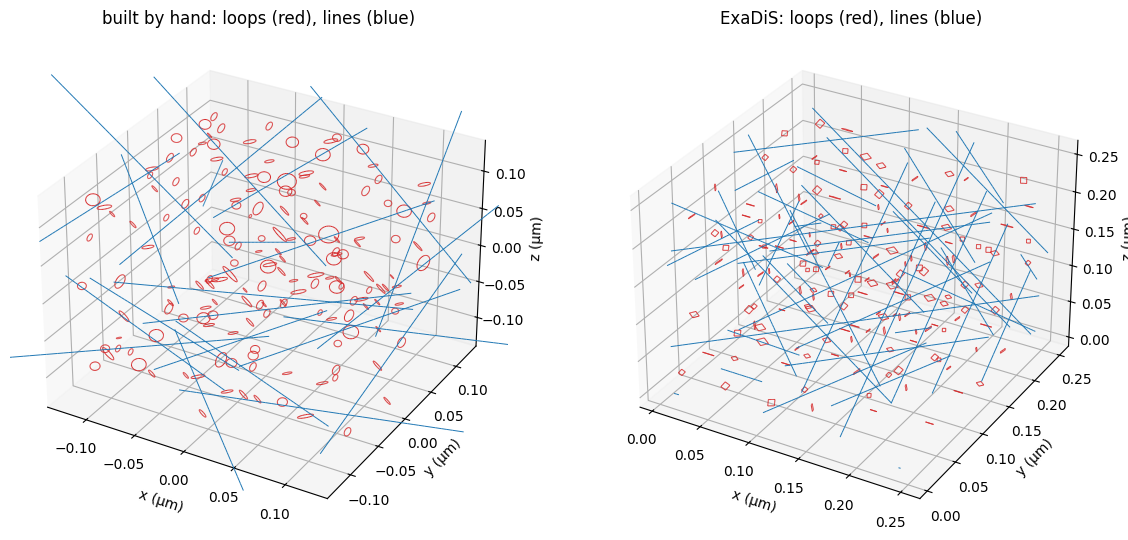

In [9]:
def draw(ax, net, color, lw=0.7):
    a = net.nodes_um[net.segments[:, 0]]
    b = a + net.segment_vectors_um()
    ax.add_collection3d(Line3DCollection(np.stack([a.numpy(), b.numpy()], axis=1), colors=color, linewidths=lw))

fig = plt.figure(figsize=(12, 5.5))
for i, (title, nets) in enumerate((("built by hand", [(loop_net, "C3"), (line_net, "C0")]),
                                   ("ExaDiS", [(exa_loops, "C3"), (exa_lines, "C0")]))):
    ax = fig.add_subplot(1, 2, i + 1, projection="3d")
    for net, colour in nets:
        draw(ax, net, colour)
    lo, hi = nets[0][0].cell_min_um.numpy(), nets[0][0].cell_max_um.numpy()
    pad = 0.05 * (hi - lo)
    ax.set_xlim(lo[0] - pad[0], hi[0] + pad[0]); ax.set_ylim(lo[1] - pad[1], hi[1] + pad[1]); ax.set_zlim(lo[2] - pad[2], hi[2] + pad[2])
    ax.set_xlabel("x (µm)"); ax.set_ylabel("y (µm)"); ax.set_zlabel("z (µm)")
    ax.set_title(f"{title}: loops (red), lines (blue)")
plt.tight_layout()

## 7 · Round trip, and ExaDiS in-process

`write_paradis` writes a network back out in the same format, so something built or edited here can go back into ExaDiS. The round trip below must preserve every count.

If ExaDiS is built on your machine (`cmake .. -DEXADIS_PYTHON_BINDING=On`, with its `python/` directory on `PYTHONPATH`), `midas_ddd.exadis` calls its generators directly. That cell skips cleanly when `pyexadis` is not importable.

In [10]:
with tempfile.TemporaryDirectory() as tmp:
    path = Path(tmp) / "roundtrip.data"
    write_paradis(exa_both, path)
    back = read_paradis(path, b_magnitude_A=2.556)
print("nodes", exa_both.n_nodes, "->", back.n_nodes, "; segments", exa_both.n_segments, "->", back.n_segments)
print("line length", round(exa_both.total_line_length_um(), 6), "->", round(back.total_line_length_um(), 6), "um")

nodes 5724 -> 5724 ; segments 5724 -> 5724
line length 12.461453 -> 12.461453 um


In [11]:
from midas_ddd.exadis import have_pyexadis

if have_pyexadis():
    from midas_ddd.exadis import generate_line_config, generate_prismatic_config
    live_loops = generate_prismatic_config(crystal="fcc", box_size_b=1000, num_loops=20, radius_b=[15, 30],
                                           b_magnitude_A=2.556, maxseg_b=4, seed=1)
    live_lines = generate_line_config(crystal="fcc", box_size_b=1000, num_lines=24, theta_deg=[0, 30, 60, 90],
                                      b_magnitude_A=2.556, maxseg_b=20, seed=2)
    _ = summarise("ExaDiS in-process loops", live_loops)
    _ = summarise("ExaDiS in-process lines", live_lines)
else:
    print("pyexadis is not importable here, so this cell does nothing. The file bridge above is all "
          "notebook 2 needs. To generate your own networks, run ExaDiS anywhere, call its "
          "write_data(N, 'net.data'), and read the file with read_paradis(..., b_magnitude_A=...).")

pyexadis is not importable here, so this cell does nothing. The file bridge above is all notebook 2 needs. To generate your own networks, run ExaDiS anywhere, call its write_data(N, 'net.data'), and read the file with read_paradis(..., b_magnitude_A=...).


## Next

Notebook `midas_saxs/notebooks/01_saxs_image_from_dislocations.ipynb` puts these networks on a SAXS detector.

**What to carry into it:**

* Loops scatter through their relaxation volume. Along a loop's own normal the small-angle amplitude is exactly zero.
* Lines are *not* invisible at small angle, but character decides everything: an edge or mixed line scatters into a thin sheet perpendicular to itself, and a screw in isotropic or cubic elasticity does not scatter at all. The 24 ExaDiS lines shipped with this notebook are all pure screws, so notebook 2 uses a population generated with `theta_deg=[0, 30, 60, 90]` in a larger 4000 b cell.
* A periodic line has a scattering amplitude only on the simulation cell's reciprocal lattice. Between lattice points the SAXS forward shows it at a stated resolution (default two lattice spacings) and reports a low-q floor of about three lattice spacings, below which the cell's own periodicity dominates; a bigger cell lowers the floor. That treatment is preregistered and under adversarial verification, not established.
* For scattering, prefer networks whose lines have no free ends: periodic ExaDiS lines, or closed loops.